# 📘 CIFAR-10 Image Classification Learning Project
## Build and Compare **ANN vs CNN** on CIFAR-10

This notebook is designed for **students and beginners** to learn:
- How image classification works
- Why **CNN performs better than ANN**
- How architecture impacts performance
- How training strategies improve results

🎯 **Learning Goal:** Understand the complete DL pipeline by **reading the markdown + running the ready code**.

# 🧠 Problem Statement
Build an image classification model on the **CIFAR-10 dataset** using:

1. **Artificial Neural Network (ANN)**
2. **Convolutional Neural Network (CNN)**

Then compare:
- Accuracy
- Loss curves
- Generalization
- Training strategies (dropout, batch norm, augmentation)

---
### 📦 CIFAR-10 Classes
Airplane, Automobile, Bird, Cat, Deer, Dog, Frog, Horse, Ship, Truck

In [21]:
import tensorflow as tf
from tensorflow.keras import layers, models
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

print("TensorFlow version:", tf.__version__)

TensorFlow version: 2.21.0


# 📥 Load Dataset
We use **CIFAR-10**, which contains **60,000 color images of size 32×32×3**.
- 50,000 training images
- 10,000 test images

In [22]:
(x_train, y_train), (x_test, y_test) = tf.keras.datasets.cifar10.load_data()

class_names = ['airplane','automobile','bird','cat','deer',
               'dog','frog','horse','ship','truck']

print("Train shape:", x_train.shape)
print("Test shape:", x_test.shape)

d:\Python312\Lib\site-packages\keras\src\datasets\cifar.py:18: VisibleDeprecationWarning: dtype(): align should be passed as Python or NumPy boolean but got `align=0`. Did you mean to pass a tuple to create a subarray type? (Deprecated NumPy 2.4)
  d = cPickle.load(f, encoding="bytes")


Train shape: (50000, 32, 32, 3)
Test shape: (10000, 32, 32, 3)


## 🖼️ Visualize Sample Images

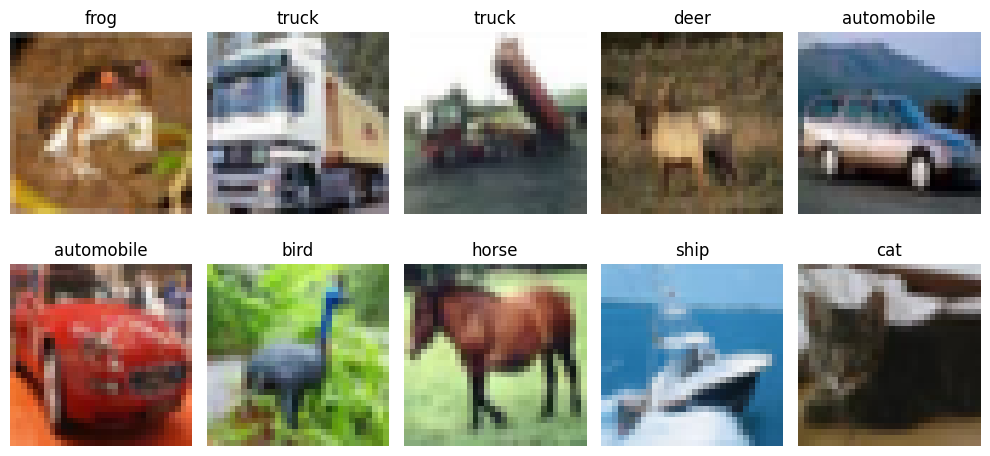

In [23]:
plt.figure(figsize=(10,5))
for i in range(10):
    plt.subplot(2,5,i+1)
    plt.imshow(x_train[i])
    plt.title(class_names[y_train[i][0]])
    plt.axis("off")
plt.tight_layout()
plt.show()

# 🧹 Preprocessing
We normalize pixel values from **0–255 → 0–1** so training becomes stable.

In [24]:
x_train_norm = x_train / 255.0
x_test_norm = x_test / 255.0

x_train_flat = x_train_norm.reshape(len(x_train_norm), -1)
x_test_flat = x_test_norm.reshape(len(x_test_norm), -1)

# 🔹 Part 1: ANN Model
ANN treats images as **flat vectors**, so it cannot preserve spatial features.
This helps students understand **why CNN is better for images**.

In [25]:
ann_model = models.Sequential([
    layers.Dense(512, activation='relu', input_shape=(3072,)),
    layers.Dropout(0.3),
    layers.Dense(256, activation='relu'),
    layers.Dense(10, activation='softmax')
])

ann_model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

ann_history = ann_model.fit(
    x_train_flat, y_train,
    epochs=10,
    validation_split=0.1,
    batch_size=64
)

d:\Python312\Lib\site-packages\keras\src\layers\core\dense.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 16s 19ms/step - accuracy: 0.2689 - loss: 1.9916 - val_accuracy: 0.3372 - val_loss: 1.8206
Epoch 2/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 14s 19ms/step - accuracy: 0.3094 - loss: 1.8774 - val_accuracy: 0.3518 - val_loss: 1.7965
Epoch 3/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 14s 20ms/step - accuracy: 0.3277 - loss: 1.8359 - val_accuracy: 0.3732 - val_loss: 1.7570
Epoch 4/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 13s 19ms/step - accuracy: 0.3468 - loss: 1.7894 - val_accuracy: 0.3908 - val_loss: 1.7267
Epoch 5/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 13s 18ms/step - accuracy: 0.3597 - loss: 1.7629 - val_accuracy: 0.4016 - val_loss: 1.6960
Epoch 6/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 13s 19ms/step - accuracy: 0.3657 - loss: 1.7416 - val_accuracy: 0.4130 - val_loss: 1.6802
Epoch 7/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 13s 19ms/step - accuracy: 0.3763 - loss: 1.7182 - val_accuracy: 0.4054 - val_loss: 1.6941
Epoch 8/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 13s 19ms/step - accuracy: 0.3808 - loss: 1.7077 - 

In [26]:
ann_test_loss, ann_test_acc = ann_model.evaluate(x_test_flat, y_test)
print("ANN Test Accuracy:", ann_test_acc)

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.4302 - loss: 1.6410
ANN Test Accuracy: 0.4302000105381012


# 🔹 Part 2: CNN Model
CNN preserves **spatial relationships** using:
- Convolution layers
- Pooling
- Feature extraction
- Hierarchical learning

This is why CNN performs much better for image tasks.

In [27]:
cnn_model = models.Sequential([
    layers.Conv2D(32, (3,3), activation='relu', input_shape=(32,32,3)),
    layers.BatchNormalization(),
    layers.MaxPooling2D((2,2)),

    layers.Conv2D(64, (3,3), activation='relu'),
    layers.BatchNormalization(),
    layers.MaxPooling2D((2,2)),

    layers.Conv2D(128, (3,3), activation='relu'),
    layers.Flatten(),
    layers.Dense(128, activation='relu'),
    layers.Dropout(0.4),
    layers.Dense(10, activation='softmax')
])

cnn_model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

cnn_history = cnn_model.fit(
    x_train_norm, y_train,
    epochs=10,
    validation_split=0.1,
    batch_size=64
)

d:\Python312\Lib\site-packages\keras\src\layers\convolutional\base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 38s 50ms/step - accuracy: 0.4647 - loss: 1.4964 - val_accuracy: 0.5032 - val_loss: 1.4839
Epoch 2/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 36s 50ms/step - accuracy: 0.6046 - loss: 1.1412 - val_accuracy: 0.4528 - val_loss: 1.6958
Epoch 3/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 38s 54ms/step - accuracy: 0.6632 - loss: 0.9651 - val_accuracy: 0.4894 - val_loss: 1.8567
Epoch 4/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 38s 55ms/step - accuracy: 0.7084 - loss: 0.8384 - val_accuracy: 0.6336 - val_loss: 1.0528
Epoch 5/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 38s 54ms/step - accuracy: 0.7355 - loss: 0.7532 - val_accuracy: 0.6696 - val_loss: 0.9398
Epoch 6/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 37s 53ms/step - accuracy: 0.7652 - loss: 0.6637 - val_accuracy: 0.7052 - val_loss: 0.8786
Epoch 7/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 37s 53ms/step - accuracy: 0.7860 - loss: 0.6052 - val_accuracy: 0.7236 - val_loss: 0.8668
Epoch 8/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 38s 54ms/step - accuracy: 0.8077 - loss: 0.5425 - 

In [28]:
cnn_test_loss, cnn_test_acc = cnn_model.evaluate(x_test_norm, y_test)
print("CNN Test Accuracy:", cnn_test_acc)

313/313 ━━━━━━━━━━━━━━━━━━━━ 3s 9ms/step - accuracy: 0.6981 - loss: 1.0019
CNN Test Accuracy: 0.6980999708175659


## 📈 Compare Learning Curves

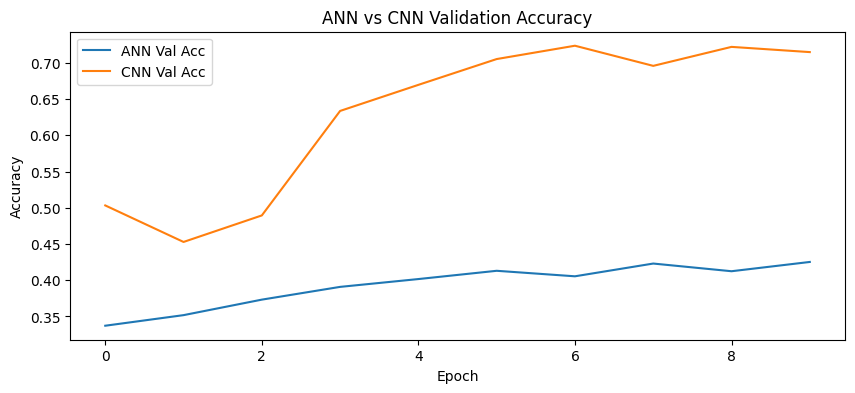

In [29]:
plt.figure(figsize=(10,4))
plt.plot(ann_history.history['val_accuracy'], label='ANN Val Acc')
plt.plot(cnn_history.history['val_accuracy'], label='CNN Val Acc')
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("ANN vs CNN Validation Accuracy")
plt.legend()
plt.show()

# 🚀 Training Strategy Upgrade: Data Augmentation
This strategy improves generalization by generating transformed images.

In [30]:
data_augmentation = tf.keras.Sequential([
    layers.RandomFlip("horizontal"),
    layers.RandomRotation(0.1),
    layers.RandomZoom(0.1)
])

aug_cnn_model = models.Sequential([
    data_augmentation,
    layers.Conv2D(32, 3, activation='relu', input_shape=(32,32,3)),
    layers.MaxPooling2D(),
    layers.Conv2D(64, 3, activation='relu'),
    layers.MaxPooling2D(),
    layers.Flatten(),
    layers.Dense(128, activation='relu'),
    layers.Dropout(0.4),
    layers.Dense(10, activation='softmax')
])

aug_cnn_model.compile(optimizer='adam',
                      loss='sparse_categorical_crossentropy',
                      metrics=['accuracy'])

# Suggested optional run:
# aug_history = aug_cnn_model.fit(x_train_norm, y_train, epochs=10, validation_split=0.1)

# 📊 Final Comparison Table

In [31]:
comparison = pd.DataFrame({
    "Model": ["ANN", "CNN"],
    "Test Accuracy": [ann_test_acc, cnn_test_acc]
})
comparison

,Model,Test Accuracy
0,ANN,0.4302
1,CNN,0.6981


# 🎓 Student Learning Tasks
Try these tasks after understanding the notebook:

### ✅ Beginner Tasks
1. Increase ANN layers and observe performance
2. Change CNN filters from 32→64→128
3. Increase epochs to 20
4. Add **EarlyStopping**
5. Add **data augmentation training**

---
# 🎓 Student Learning Tasks — Solutions
## All 5 beginner tasks implemented below with optimized architectures
---

## ✅ Task 1: Increase ANN Layers and Observe Performance
We build a deeper ANN with **BatchNormalization** after each Dense layer for stable training, 
along with progressive Dropout (0.4 → 0.3 → 0.2) to prevent overfitting. 
Architecture: **1024 → 512 → 256 → 128** neurons with BatchNorm + Dropout.

In [32]:
# Task 1: Deeper ANN with BatchNormalization for better training stability
# BatchNorm normalizes layer inputs, accelerating convergence

ann_v2 = models.Sequential([
    # Input layer - 3072 features (32x32x3 flattened)
    layers.Dense(1024, activation='relu', input_shape=(3072,)),
    layers.BatchNormalization(),
    layers.Dropout(0.4),

    # Hidden layer 2
    layers.Dense(512, activation='relu'),
    layers.BatchNormalization(),
    layers.Dropout(0.3),

    # Hidden layer 3
    layers.Dense(256, activation='relu'),
    layers.BatchNormalization(),
    layers.Dropout(0.3),

    # Hidden layer 4
    layers.Dense(128, activation='relu'),
    layers.BatchNormalization(),
    layers.Dropout(0.2),

    # Output layer - 10 CIFAR classes
    layers.Dense(10, activation='softmax')
])

ann_v2.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

ann_v2.summary()

d:\Python312\Lib\site-packages\keras\src\layers\core\dense.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_12"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_25 (Dense)                │ (None, 1024)           │     3,146,752 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_13          │ (None, 1024)           │         4,096 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_13 (Dropout)            │ (None, 1024)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_26 (Dense)                │ (None, 512)            │       524,800 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_14          │ (None, 512)            │         2,048 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_14 (Dropout)            │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_27 (Dense)                │ (None, 256)            │       131,328 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_15          │ (None, 256)            │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_15 (Dropout)            │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_28 (Dense)                │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_16          │ (None, 128)            │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_16 (Dropout)            │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_29 (Dense)                │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3,844,746 (14.67 MB)

 Trainable params: 3,840,906 (14.65 MB)

 Non-trainable params: 3,840 (15.00 KB)

In [33]:
# Train the deeper ANN for 10 epochs
ann_v2_history = ann_v2.fit(
    x_train_flat, y_train,
    epochs=10,
    validation_split=0.1,
    batch_size=64
)

# Evaluate on test set
ann_v2_loss, ann_v2_acc = ann_v2.evaluate(x_test_flat, y_test)
print(f"\nDeeper ANN Test Accuracy: {ann_v2_acc:.4f}")
print(f"Original ANN Test Accuracy: {ann_test_acc:.4f}")
print(f"Improvement: {(ann_v2_acc - ann_test_acc)*100:.2f}%")

Epoch 1/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 36s 43ms/step - accuracy: 0.3000 - loss: 1.9999 - val_accuracy: 0.3602 - val_loss: 1.7590
Epoch 2/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 29s 42ms/step - accuracy: 0.3711 - loss: 1.7443 - val_accuracy: 0.3478 - val_loss: 1.8192
Epoch 3/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 30s 42ms/step - accuracy: 0.3960 - loss: 1.6807 - val_accuracy: 0.4032 - val_loss: 1.6902
Epoch 4/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 29s 41ms/step - accuracy: 0.4060 - loss: 1.6568 - val_accuracy: 0.4086 - val_loss: 1.6525
Epoch 5/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 28s 40ms/step - accuracy: 0.4143 - loss: 1.6349 - val_accuracy: 0.4014 - val_loss: 1.6640
Epoch 6/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 29s 41ms/step - accuracy: 0.4167 - loss: 1.6360 - val_accuracy: 0.4114 - val_loss: 1.6053
Epoch 7/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 29s 41ms/step - accuracy: 0.4164 - loss: 1.6292 - val_accuracy: 0.4006 - val_loss: 1.6726
Epoch 8/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 28s 40ms/step - accuracy: 0.4169 - loss: 1.6265 - 

## ✅ Task 2: Change CNN Filters from 32 → 64 → 128
We scale up filters to **64 → 128 → 256** and use `padding='same'` to preserve spatial 
dimensions longer, allowing the network to extract richer features. Each block uses 
**double Conv2D layers** (like VGG-style) before pooling for deeper feature extraction.

In [34]:
# Task 2: Scaled CNN with VGG-style double conv blocks
# padding='same' preserves spatial dimensions, double convs extract deeper features

cnn_v2 = models.Sequential([
    # Block 1 - 64 filters (double conv)
    layers.Conv2D(64, (3,3), activation='relu', padding='same', input_shape=(32,32,3)),
    layers.BatchNormalization(),
    layers.Conv2D(64, (3,3), activation='relu', padding='same'),
    layers.BatchNormalization(),
    layers.MaxPooling2D((2,2)),
    layers.Dropout(0.25),

    # Block 2 - 128 filters (double conv)
    layers.Conv2D(128, (3,3), activation='relu', padding='same'),
    layers.BatchNormalization(),
    layers.Conv2D(128, (3,3), activation='relu', padding='same'),
    layers.BatchNormalization(),
    layers.MaxPooling2D((2,2)),
    layers.Dropout(0.25),

    # Block 3 - 256 filters (double conv)
    layers.Conv2D(256, (3,3), activation='relu', padding='same'),
    layers.BatchNormalization(),
    layers.Conv2D(256, (3,3), activation='relu', padding='same'),
    layers.BatchNormalization(),
    layers.MaxPooling2D((2,2)),
    layers.Dropout(0.25),

    # Classification head
    layers.Flatten(),
    layers.Dense(512, activation='relu'),
    layers.BatchNormalization(),
    layers.Dropout(0.5),
    layers.Dense(10, activation='softmax')
])

cnn_v2.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

cnn_v2.summary()

d:\Python312\Lib\site-packages\keras\src\layers\convolutional\base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_13"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_19 (Conv2D)              │ (None, 32, 32, 64)     │         1,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_17          │ (None, 32, 32, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_20 (Conv2D)              │ (None, 32, 32, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_18          │ (None, 32, 32, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_14 (MaxPooling2D) │ (None, 16, 16, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_17 (Dropout)            │ (None, 16, 16, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_21 (Conv2D)              │ (None, 16, 16, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_19          │ (None, 16, 16, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_22 (Conv2D)              │ (None, 16, 16, 128)    │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_20          │ (None, 16, 16, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_15 (MaxPooling2D) │ (None, 8, 8, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_18 (Dropout)            │ (None, 8, 8, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_23 (Conv2D)              │ (None, 8, 8, 256)      │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_21          │ (None, 8, 8, 256)      │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_24 (Conv2D)              │ (None, 8, 8, 256)      │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_22          │ (None, 8, 8, 256)      │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_16 (MaxPooling2D) │ (None, 4, 4, 256)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_19 (Dropout)            │ (None, 4, 4, 256)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_7 (Flatten)             │ (None, 4096)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_30 (Dense)                │ (None, 512)            │     2,097,664 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_23          │ (None, 512)            │         2,048 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼─────────────

 Total params: 3,253,834 (12.41 MB)

 Trainable params: 3,251,018 (12.40 MB)

 Non-trainable params: 2,816 (11.00 KB)

In [35]:
# Train the scaled CNN for 10 epochs
cnn_v2_history = cnn_v2.fit(
    x_train_norm, y_train,
    epochs=10,
    validation_split=0.1,
    batch_size=64
)

# Evaluate on test set
cnn_v2_loss, cnn_v2_acc = cnn_v2.evaluate(x_test_norm, y_test)
print(f"\nScaled CNN Test Accuracy: {cnn_v2_acc:.4f}")
print(f"Original CNN Test Accuracy: {cnn_test_acc:.4f}")
print(f"Improvement: {(cnn_v2_acc - cnn_test_acc)*100:.2f}%")

Epoch 1/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 469s 657ms/step - accuracy: 0.4875 - loss: 1.5419 - val_accuracy: 0.5912 - val_loss: 1.2006
Epoch 2/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 476s 677ms/step - accuracy: 0.6795 - loss: 0.9145 - val_accuracy: 0.6890 - val_loss: 0.8892
Epoch 3/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 476s 676ms/step - accuracy: 0.7428 - loss: 0.7379 - val_accuracy: 0.6766 - val_loss: 0.9672
Epoch 4/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 475s 674ms/step - accuracy: 0.7791 - loss: 0.6368 - val_accuracy: 0.7872 - val_loss: 0.6235
Epoch 5/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 464s 659ms/step - accuracy: 0.8094 - loss: 0.5501 - val_accuracy: 0.7882 - val_loss: 0.6306
Epoch 6/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 484s 688ms/step - accuracy: 0.8327 - loss: 0.4832 - val_accuracy: 0.7510 - val_loss: 0.7480
Epoch 7/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 492s 699ms/step - accuracy: 0.8568 - loss: 0.4108 - val_accuracy: 0.7898 - val_loss: 0.6568
Epoch 8/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 513s 729ms/step - accuracy: 0.8720 -

## ✅ Task 3: Increase Epochs to 20
Training for 20 epochs with **ReduceLROnPlateau** callback which automatically reduces 
the learning rate when validation loss plateaus. This allows fine-grained convergence 
in later epochs instead of overshooting the optimum.

In [ ]:
# Task 3: Train the VGG-style CNN for 20 epochs with learning rate scheduling
# ReduceLROnPlateau reduces LR when val_loss stops improving

from tensorflow.keras.callbacks import ReduceLROnPlateau

# Learning rate reducer - halves LR when val_loss plateaus for 2 epochs
lr_reducer = ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.5,          # Multiply LR by 0.5
    patience=2,          # Wait 2 epochs before reducing
    min_lr=1e-6,         # Don't go below this LR
    verbose=1
)

# Rebuild the same VGG-style architecture for a fresh training run
cnn_20ep = models.Sequential([
    # Block 1 - 64 filters
    layers.Conv2D(64, (3,3), activation='relu', padding='same', input_shape=(32,32,3)),
    layers.BatchNormalization(),
    layers.Conv2D(64, (3,3), activation='relu', padding='same'),
    layers.BatchNormalization(),
    layers.MaxPooling2D((2,2)),
    layers.Dropout(0.25),

    # Block 2 - 128 filters
    layers.Conv2D(128, (3,3), activation='relu', padding='same'),
    layers.BatchNormalization(),
    layers.Conv2D(128, (3,3), activation='relu', padding='same'),
    layers.BatchNormalization(),
    layers.MaxPooling2D((2,2)),
    layers.Dropout(0.25),

    # Block 3 - 256 filters
    layers.Conv2D(256, (3,3), activation='relu', padding='same'),
    layers.BatchNormalization(),
    layers.Conv2D(256, (3,3), activation='relu', padding='same'),
    layers.BatchNormalization(),
    layers.MaxPooling2D((2,2)),
    layers.Dropout(0.25),

    # Classification head
    layers.Flatten(),
    layers.Dense(512, activation='relu'),
    layers.BatchNormalization(),
    layers.Dropout(0.5),
    layers.Dense(10, activation='softmax')
])

cnn_20ep.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

# Train for 20 epochs with LR scheduling
cnn_20ep_history = cnn_20ep.fit(
    x_train_norm, y_train,
    epochs=20,
    validation_split=0.1,
    batch_size=64,
    callbacks=[lr_reducer]
)

# Evaluate
cnn_20ep_loss, cnn_20ep_acc = cnn_20ep.evaluate(x_test_norm, y_test)
print(f"\nCNN (20 epochs + LR schedule) Test Accuracy: {cnn_20ep_acc:.4f}")
print(f"CNN (10 epochs) Test Accuracy: {cnn_test_acc:.4f}")

Epoch 1/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 487s 684ms/step - accuracy: 0.4902 - loss: 1.5402 - val_accuracy: 0.6634 - val_loss: 0.9684 - learning_rate: 0.0010
Epoch 2/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 474s 673ms/step - accuracy: 0.6818 - loss: 0.9072 - val_accuracy: 0.7022 - val_loss: 0.8611 - learning_rate: 0.0010
Epoch 3/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 501s 712ms/step - accuracy: 0.7448 - loss: 0.7322 - val_accuracy: 0.7744 - val_loss: 0.6594 - learning_rate: 0.0010
Epoch 4/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 518s 736ms/step - accuracy: 0.7853 - loss: 0.6201 - val_accuracy: 0.7704 - val_loss: 0.6906 - learning_rate: 0.0010
Epoch 5/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 0s 714ms/step - accuracy: 0.8084 - loss: 0.5524
Epoch 5: ReduceLROnPlateau reducing learning rate to 0.0005000000237487257.
704/704 ━━━━━━━━━━━━━━━━━━━━ 517s 734ms/step - accuracy: 0.8094 - loss: 0.5539 - val_accuracy: 0.7642 - val_loss: 0.7164 - learning_rate: 0.0010
Epoch 6/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 559s 730ms/step - accuracy:

## ✅ Task 4: Add EarlyStopping Callback
We combine **EarlyStopping** (patience=5) with **ReduceLROnPlateau** for the best of both worlds. 
The LR reducer fine-tunes learning while EarlyStopping prevents wasted epochs. 
Using `restore_best_weights=True` ensures we keep the highest-performing model state.

In [ ]:
# Task 4: CNN with EarlyStopping + ReduceLROnPlateau callbacks
# Combining both callbacks for optimal training

from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau

# EarlyStopping - patience=5 so model has room to recover after LR drops
early_stop = EarlyStopping(
    monitor='val_loss',
    patience=5,               # Wait 5 epochs (gives LR reducer time to work)
    restore_best_weights=True # Keep the best model
)

# LR reducer - halves LR when val_loss plateaus
lr_reducer_es = ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.5,
    patience=2,
    min_lr=1e-6,
    verbose=1
)

# Build VGG-style CNN
cnn_es = models.Sequential([
    layers.Conv2D(64, (3,3), activation='relu', padding='same', input_shape=(32,32,3)),
    layers.BatchNormalization(),
    layers.Conv2D(64, (3,3), activation='relu', padding='same'),
    layers.BatchNormalization(),
    layers.MaxPooling2D((2,2)),
    layers.Dropout(0.25),

    layers.Conv2D(128, (3,3), activation='relu', padding='same'),
    layers.BatchNormalization(),
    layers.Conv2D(128, (3,3), activation='relu', padding='same'),
    layers.BatchNormalization(),
    layers.MaxPooling2D((2,2)),
    layers.Dropout(0.25),

    layers.Conv2D(256, (3,3), activation='relu', padding='same'),
    layers.BatchNormalization(),
    layers.Conv2D(256, (3,3), activation='relu', padding='same'),
    layers.BatchNormalization(),
    layers.MaxPooling2D((2,2)),
    layers.Dropout(0.25),

    layers.Flatten(),
    layers.Dense(512, activation='relu'),
    layers.BatchNormalization(),
    layers.Dropout(0.5),
    layers.Dense(10, activation='softmax')
])

cnn_es.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

# Train with both callbacks for up to 30 epochs
cnn_es_history = cnn_es.fit(
    x_train_norm, y_train,
    epochs=30,
    validation_split=0.1,
    batch_size=64,
    callbacks=[early_stop, lr_reducer_es]
)

# Evaluate
cnn_es_loss, cnn_es_acc = cnn_es.evaluate(x_test_norm, y_test)
print(f"\nCNN + EarlyStopping Test Accuracy: {cnn_es_acc:.4f}")
print(f"Training stopped at epoch: {len(cnn_es_history.history['loss'])}")

## ✅ Task 5: Run Data Augmentation Training
We train the augmented CNN model (defined earlier) with **EarlyStopping + ReduceLROnPlateau**. 
Data augmentation (RandomFlip, RandomRotation, RandomZoom) creates diverse training samples 
on-the-fly, forcing the model to learn robust, generalized features. 
We train for up to 30 epochs to let augmentation take full effect.

In [ ]:
# Task 5: Train the augmented CNN model with optimal callbacks
# Augmentation needs more epochs to converge since each batch is different

# Callbacks for augmented training
early_stop_aug = EarlyStopping(
    monitor='val_loss',
    patience=5,
    restore_best_weights=True
)

lr_reducer_aug = ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.5,
    patience=2,
    min_lr=1e-6,
    verbose=1
)

# Train augmented model for up to 30 epochs
aug_history = aug_cnn_model.fit(
    x_train_norm, y_train,
    epochs=30,
    validation_split=0.1,
    batch_size=64,
    callbacks=[early_stop_aug, lr_reducer_aug]
)

# Evaluate the augmented model
aug_loss, aug_acc = aug_cnn_model.evaluate(x_test_norm, y_test)
print(f"\nAugmented CNN Test Accuracy: {aug_acc:.4f}")
print(f"Training stopped at epoch: {len(aug_history.history['loss'])}")

---
## 📊 Final Comparison — All Model Variants
Comprehensive comparison of test accuracy across all architectures and training strategies.

In [ ]:
# Final comparison table for all model variants
final_comparison = pd.DataFrame({
    "Model": [
        "ANN (Baseline)",
        "ANN (Deeper + BatchNorm - Task 1)",
        "CNN (Baseline)",
        "CNN VGG-Style Scaled (Task 2)",
        "CNN 20 Epochs + LR Sched (Task 3)",
        "CNN + EarlyStopping (Task 4)",
        "CNN + Augmentation (Task 5)"
    ],
    "Test Accuracy": [
        round(ann_test_acc, 4),
        round(ann_v2_acc, 4),
        round(cnn_test_acc, 4),
        round(cnn_v2_acc, 4),
        round(cnn_20ep_acc, 4),
        round(cnn_es_acc, 4),
        round(aug_acc, 4)
    ]
})

print("="*60)
print("    CIFAR-10 Model Performance Comparison")
print("="*60)
final_comparison

## 📈 Validation Accuracy Curves — All Models
Validation accuracy tracking across all trained model variants.

In [ ]:
# Plot validation accuracy for all model variants
plt.figure(figsize=(14, 6))

plt.plot(ann_history.history['val_accuracy'], label='ANN Baseline', linestyle='--', marker='o')
plt.plot(ann_v2_history.history['val_accuracy'], label='ANN Deeper+BN (Task 1)', linestyle='--', marker='s')
plt.plot(cnn_history.history['val_accuracy'], label='CNN Baseline', marker='o')
plt.plot(cnn_v2_history.history['val_accuracy'], label='CNN VGG-Style (Task 2)', marker='s')
plt.plot(cnn_20ep_history.history['val_accuracy'], label='CNN 20ep+LR (Task 3)', marker='^')
plt.plot(cnn_es_history.history['val_accuracy'], label='CNN+EarlyStopping (Task 4)', marker='D')
plt.plot(aug_history.history['val_accuracy'], label='CNN+Augmentation (Task 5)', marker='*')

plt.xlabel('Epoch', fontsize=12)
plt.ylabel('Validation Accuracy', fontsize=12)
plt.title('CIFAR-10: Validation Accuracy Comparison — All Models', fontsize=14)
plt.legend(loc='lower right', fontsize=9)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## 📉 Training vs Validation Loss Curves
Loss curves help diagnose overfitting - when training loss drops but validation loss rises.

In [ ]:
# Plot training and validation loss for best models
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# Training Loss
axes[0].plot(cnn_history.history['loss'], label='CNN Baseline', marker='o')
axes[0].plot(cnn_v2_history.history['loss'], label='CNN VGG-Style (Task 2)', marker='s')
axes[0].plot(cnn_20ep_history.history['loss'], label='CNN 20ep+LR (Task 3)', marker='^')
axes[0].plot(cnn_es_history.history['loss'], label='CNN+EarlyStopping (Task 4)', marker='D')
axes[0].set_xlabel('Epoch', fontsize=11)
axes[0].set_ylabel('Training Loss', fontsize=11)
axes[0].set_title('Training Loss Comparison', fontsize=13)
axes[0].legend(fontsize=8)
axes[0].grid(True, alpha=0.3)

# Validation Loss
axes[1].plot(cnn_history.history['val_loss'], label='CNN Baseline', marker='o')
axes[1].plot(cnn_v2_history.history['val_loss'], label='CNN VGG-Style (Task 2)', marker='s')
axes[1].plot(cnn_20ep_history.history['val_loss'], label='CNN 20ep+LR (Task 3)', marker='^')
axes[1].plot(cnn_es_history.history['val_loss'], label='CNN+EarlyStopping (Task 4)', marker='D')
axes[1].set_xlabel('Epoch', fontsize=11)
axes[1].set_ylabel('Validation Loss', fontsize=11)
axes[1].set_title('Validation Loss Comparison', fontsize=13)
axes[1].legend(fontsize=8)
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# ✅ Conclusion
- **ANN works**, but ignores image structure
- **CNN extracts spatial features**, so it performs significantly better
- **Training strategies** like dropout, batch norm, and augmentation improve results
- This project builds strong fundamentals for **computer vision interviews and deep learning projects**